# Credit Card Fraud Detection Using Machine Learning

## Project Overview

Credit card fraud is one of the most significant challenges faced by financial institutions. Fraudulent transactions account for only a tiny fraction of all transactions, making fraud detection a highly imbalanced classification problem.

The objective of this project is to build a machine learning model capable of identifying fraudulent transactions while minimizing false alarms.

## Goals

- Explore and understand the dataset
- Analyze transaction patterns
- Identify class imbalance
- Build classification models
- Compare model performance
- Detect fraudulent transactions accurately

## Dataset

The dataset contains anonymized credit card transactions made by European cardholders. Most features have been transformed using PCA for confidentiality purposes.

Target Variable:

- Class = 0 → Legitimate Transaction
- Class = 1 → Fraudulent Transaction

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df=pd.read_csv("creditcard.csv")

# Dataset Exploration

Before building any machine learning model, it is important to understand the structure of the dataset.

In this section, we examine:

- Number of observations and features
- Data types
- Missing values
- Sample records

This helps ensure that the dataset is clean and suitable for analysis.

In [14]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [17]:
df.shape

(284807, 31)

# Missing Value Analysis

Missing values can negatively affect model performance and lead to inaccurate predictions.

Therefore, we check whether any feature contains null values before proceeding with data analysis and model building.

In [18]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Observation

No missing values were found in the dataset. Therefore, no imputation or data cleaning related to missing values was required.

# visualization

<Axes: >

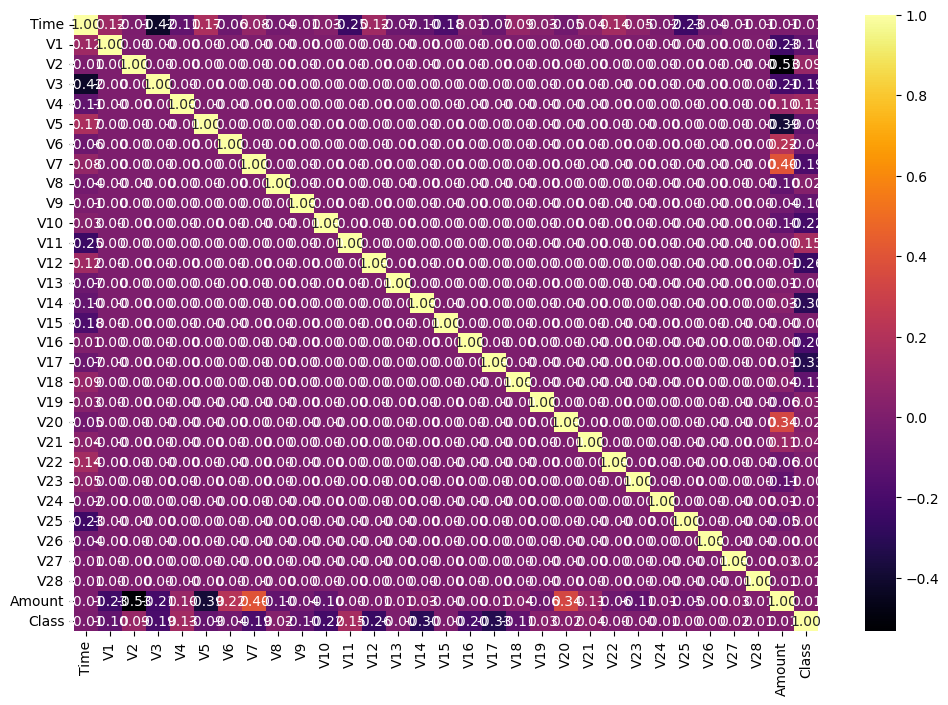

In [19]:
corr_mat=df.corr()
plt.figure(figsize=(12,8))

sns.heatmap(corr_mat,cmap="inferno",annot=True,fmt=".2f")


array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

<Figure size 1800x1200 with 0 Axes>

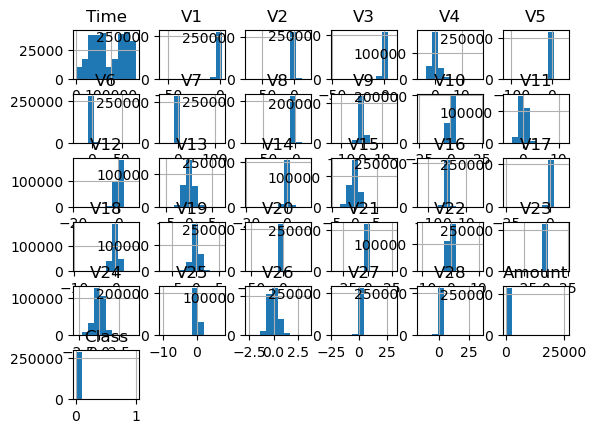

In [20]:
# fig,axes=plt.subplots(3,3
plt.figure(figsize=(18,12))
df.hist()

In [21]:
# to get relatiions higher
target_corr=corr_mat["Class"]
strong_corr=target_corr[(target_corr >0.2) | (target_corr<-0.2)]
print(strong_corr)

V10     -0.216883
V12     -0.260593
V14     -0.302544
V17     -0.326481
Class    1.000000
Name: Class, dtype: float64


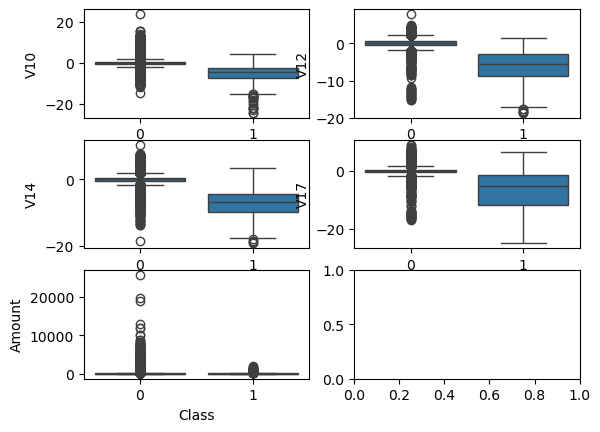

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [22]:
# imp_cols=["V1","V3","V4","V7","V10","V11","V12","V12","V14","v16","V17","V18"]
# cols=[f"V{k}" for k in range(1,18)]
# for col in cols:
#     plt.figure()
#     sns.boxplot(x="Class", y=col,data=df)
#     plt.title(f"{col} vs class")
#     # plt.xlabel("class")
#     # plt.ylabel(f"{col}")
#     plt.show()



# boxplot for imp features only 
imp_features=["V10","V12","V14","V17","Amount"]
fig,axes=plt.subplots(3,2)
axes=axes.flatten()
for i,features in enumerate(imp_features): # this will return index and value

    plt.figure()
    sns.boxplot(x="Class",y=features,data=df,ax=axes[i])

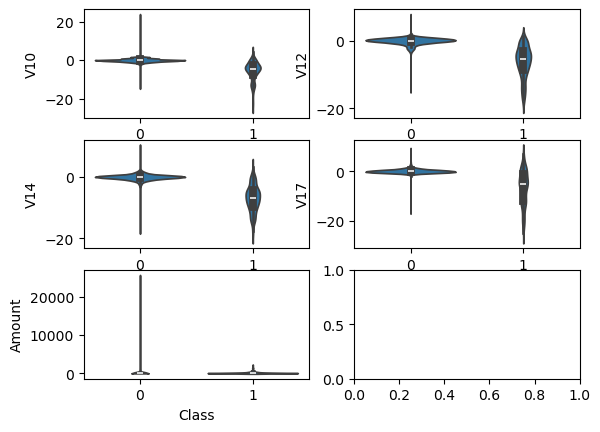

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [23]:
imp_features=["V10","V12","V14","V17","Amount"]
fig,axes=plt.subplots(3,2)
axes=axes.flatten()
for i,features in enumerate(imp_features): # this will return index and value

    plt.figure()
    sns.violinplot(x="Class",y=features,data=df,ax=axes[i])

# Class Distribution Analysis

One of the most important aspects of fraud detection is understanding the balance between fraudulent and legitimate transactions.

A count plot helps visualize how many observations belong to each class.

Purpose:
- Identify class imbalance
- Understand the difficulty of the classification problem
- Decide whether special techniques may be required during model training

<Axes: xlabel='Class', ylabel='count'>

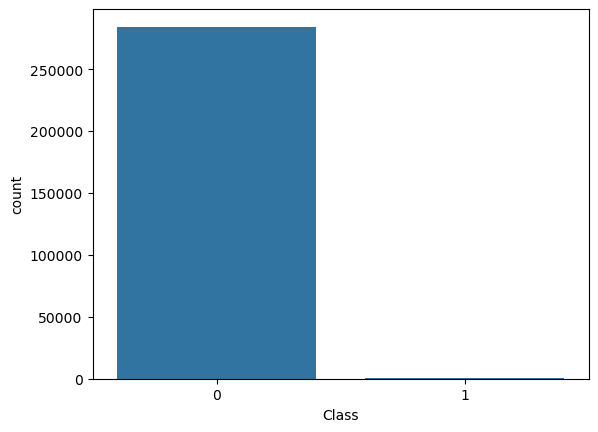

In [24]:
sns.countplot(x="Class", data=df)


### Interpretation

The visualization clearly shows a severe class imbalance.

- Class 0 (Legitimate Transactions) represents the vast majority of records.
- Class 1 (Fraudulent Transactions) represents only a very small fraction of the dataset.

This imbalance makes fraud detection challenging because a model can achieve high accuracy simply by predicting all transactions as legitimate.

Therefore, evaluation metrics such as Precision, Recall, and F1-Score are more meaningful than accuracy alone.

# Distribution of Transaction Amounts

A histogram is used to understand how transaction amounts are distributed throughout the dataset.

This visualization helps identify:

- Common transaction ranges
- Skewness in the data
- Presence of unusually large transactions

<Axes: xlabel='Amount', ylabel='Count'>

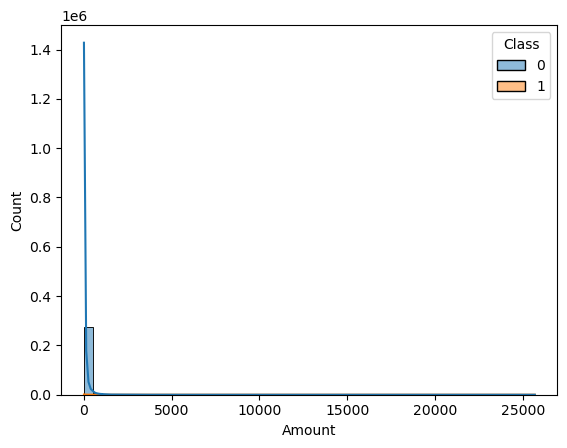

In [25]:
sns.histplot(data=df, x="Amount", hue="Class", bins=50, kde=True)


### Interpretation

The distribution is highly right-skewed.

Most transactions involve relatively small amounts, while only a few transactions involve very large amounts.

This indicates the presence of extreme values and potential outliers within the Amount feature.

# Outlier Detection Using Box Plot

A box plot provides a summary of a numerical feature by displaying:

- Median
- Quartiles
- Spread of the data
- Potential outliers

The purpose of this visualization is to identify unusually large transaction amounts.

<Axes: xlabel='Class', ylabel='Amount'>

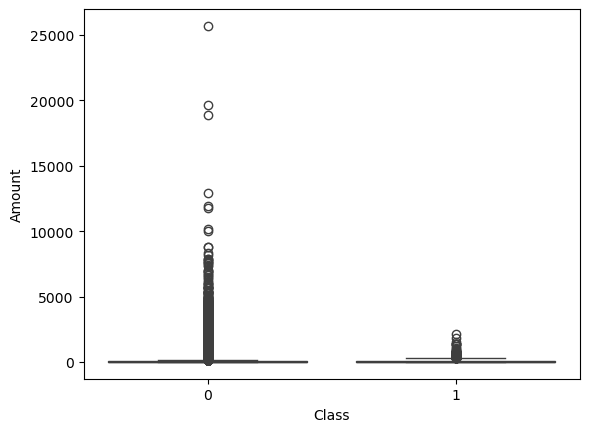

In [26]:
sns.boxplot(x="Class", y="Amount", data=df)


### Interpretation

The box plot reveals several extreme transaction amounts that lie far beyond the normal range.

These points are considered outliers and indicate that transaction amounts vary significantly across observations.

<Axes: xlabel='Amount', ylabel='Count'>

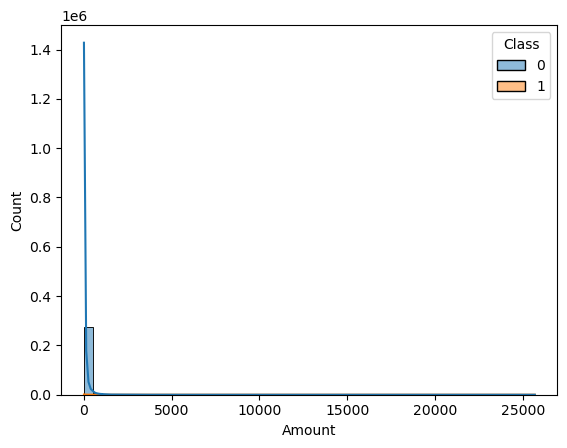

In [27]:
sns.histplot(data=df, x="Amount", hue="Class", bins=50, kde=True)




# model training

# Data Preparation

The dataset is divided into training and testing sets.

Training Set:
- Used for model learning

Testing Set:
- Used for unbiased performance evaluation



In [28]:
X=df.drop("Class",axis=1)
y=df["Class"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

# Model 1: Logistic Regression

Logistic Regression is a widely used classification algorithm that estimates the probability of a transaction belonging to a particular class.

Advantages:

- Simple and interpretable
- Fast to train
- Effective baseline model for binary classification problems

In [29]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=5000)
lr.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [30]:
p1=lr.predict(x_test)
from sklearn.metrics import classification_report
print("classification report \n",classification_report(y_test,p1))



classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.58      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [31]:
from sklearn.ensemble import  RandomForestClassifier
rfc=RandomForestClassifier(random_state=42,n_estimators=101)
rfc.fit(x_train,y_train)

,n_estimators,101
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
p2=rfc.predict(x_test)
print("Classification report \n",classification_report(y_test,p2))

Classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# Data Preparation

The dataset is divided into training and testing sets.

Training Set:
- Used for model learning

Testing Set:
- Used for unbiased performance evaluation

Stratified sampling is applied to preserve the original class distribution in both datasets.

In [33]:
# right proportion of train test split
x_train_2,x_test_2,y_train_2,y_test_2=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

In [34]:
lr=LogisticRegression(max_iter=5000)
lr.fit(x_train_2,y_train_2)
p_2=lr.predict(x_test_2)
from sklearn.metrics import classification_report
print("classification report \n",classification_report(y_test_2,p_2))


classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [37]:
from sklearn.metrics import confusion_matrix
print("Confusion metric\n",confusion_matrix(y_test_2,p_2))

Confusion metric
 [[56851    13]
 [   34    64]]


In [38]:
from sklearn.ensemble import  RandomForestClassifier
rfc=RandomForestClassifier(random_state=42,n_estimators=101)
rfc.fit(x_train_2,y_train_2)
p_3=rfc.predict(x_test_2)
print("Classification report \n",classification_report(y_test_2,p_3))

Classification report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [39]:
from sklearn.metrics import confusion_matrix
print("Confusion metric\n",confusion_matrix(y_test_2,p_3))

Confusion metric
 [[56859     5]
 [   18    80]]


# Conclusion

This project explored the application of machine learning techniques for detecting fraudulent credit card transactions.

Key Findings:

- The dataset is highly imbalanced.
- Transaction amount alone is not sufficient for fraud detection.
- Multiple features must be considered simultaneously.
- Machine learning models can effectively identify fraudulent behavior.

Models Evaluated:

- Logistic Regression
- Random Forest Classifier

Among the evaluated models, Random Forest achieved superior performance due to its ability to capture complex relationships within the data.

Future Improvements:

- Hyperparameter tuning
- Cross-validation
- SMOTE for class balancing
- XGBoost and LightGBM implementation
- Precision-Recall Curve and ROC-AUC analysis

This project demonstrates a complete machine learning workflow including data exploration, preprocessing, model training, and performance evaluation.